In [1]:
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# from class_cam_generation import CamGeneration
import class_cam_generation
from class_cam_generation import CamGeneration

# Define problem parameters. Forces are in Newtons, lengths are in meters.
user_height = 1.654 # 1.654 is avg. height of subjects 55+ in NHANES 2017-2020
k_elastic = 100
sit_angle_deg = 220
offset_angle_deg = 180
target_force_max = 100
target_force_range = 12.5
target_percentage_max = 32.5
target_percentage_range = 5
target_sitting_max = 12.5
target_radius_max = 0.0635

In [2]:
def generate_cam(x, plot=False, save=False, index=0, save_dir=None):
    """ Generates a cam from the given gear ratios, input angles, and scaling.
    """
    gear_ratios = x[: 8]
    input_angles = x[8 : -1]
    scaling = x[-1]

    Cam = CamGeneration(gear_ratios, input_angles, scaling,
                        sit_angle=np.pi/180*sit_angle_deg,
                        offset_angle=np.pi/180*offset_angle_deg)
    cam_radii, pts_inner, pts_outer, radius_max, x_cable = Cam.calculate_cam_radii(user_height,
                                                               k_elastic,
                                                               plot=plot, index=index)
    if np.any(np.isnan(pts_inner)) or np.any(np.isinf(pts_inner)):
        return np.inf, np.inf, 0, np.inf
    forces, percentages = Cam.calc_forces(cam_radii, x_cable,
                                          k_elastic, torque=False, plot=plot, index=index)
    force_max = max(forces)
    if not np.isnan(force_max):
        perc_force_max = percentages[np.where(forces == force_max)[0][0]]
        perc_sitting_ind = np.where(np.round(percentages, 1) == 0)[0][0]
        force_sitting = forces[perc_sitting_ind]

        if save:
            base = Path(save_dir) if save_dir else Path('results/cams/cams_' + dateStr)
            dir_si2st = base / 'cam_points_si2st'
            dir_stor = base / 'cam_points_stor'
            dir_si2st.mkdir(parents=True, exist_ok=True)
            dir_stor.mkdir(parents=True, exist_ok=True)
            file_si2st = dir_si2st / f'si2st_{index}.txt'
            file_outer = dir_stor / f'outer_{index}.txt'
            np.savetxt(str(file_si2st), np.append(pts_inner * 1000,
                                          np.zeros((pts_inner.shape[0], 1)),
                                          axis=1), delimiter=',')
            np.savetxt(str(file_outer), np.append(pts_outer * 1000,
                                          np.zeros((pts_outer.shape[0], 1)),
                                          axis=1), delimiter=',')

        return radius_max, perc_force_max, force_max, force_sitting
    else:
        return np.inf, np.inf, 0, np.inf

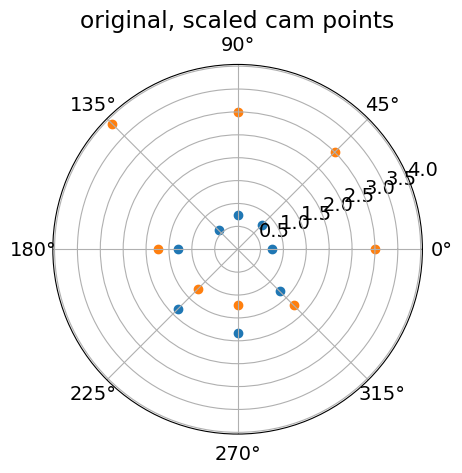

<Figure size 640x480 with 0 Axes>

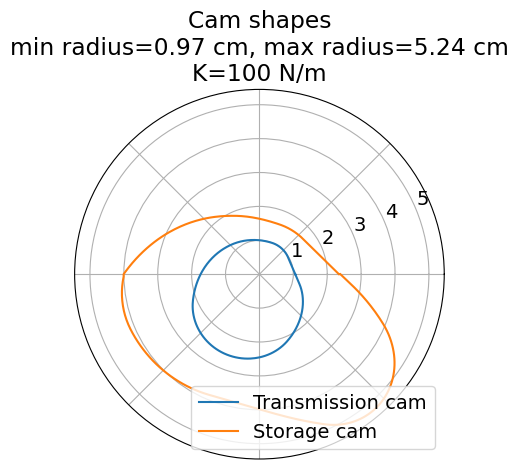

/Users/stephan/cam-mech/class_cam_generation.py:496: RuntimeWarning: invalid value encountered in divide
  gear_ratios = cam_moment_arms_stor / cam_moment_arms_trans


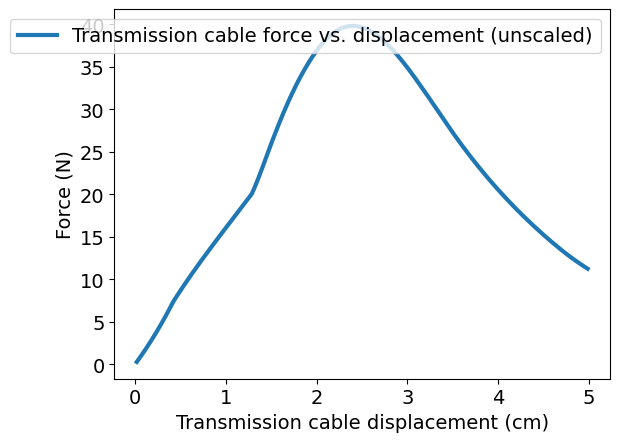

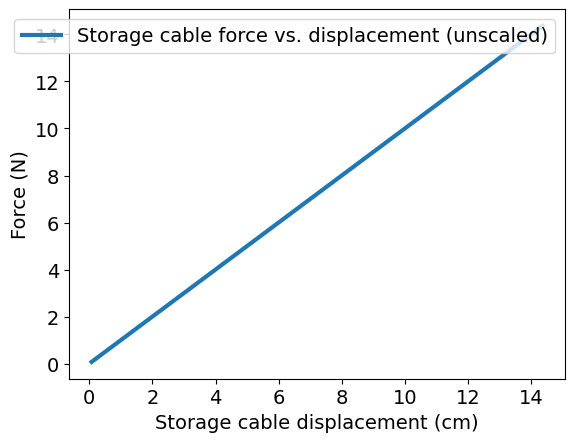

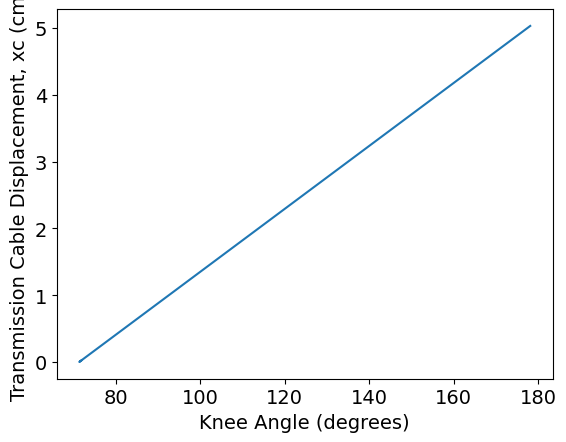

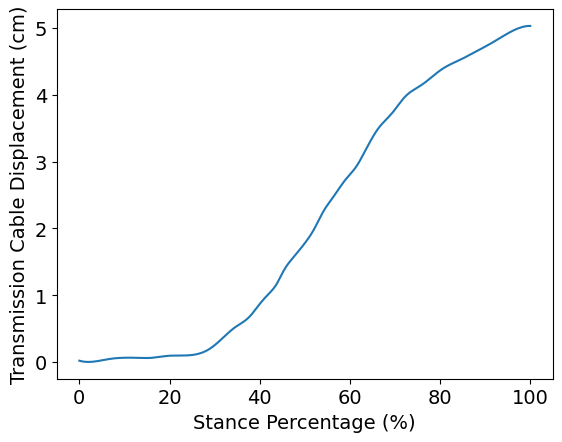

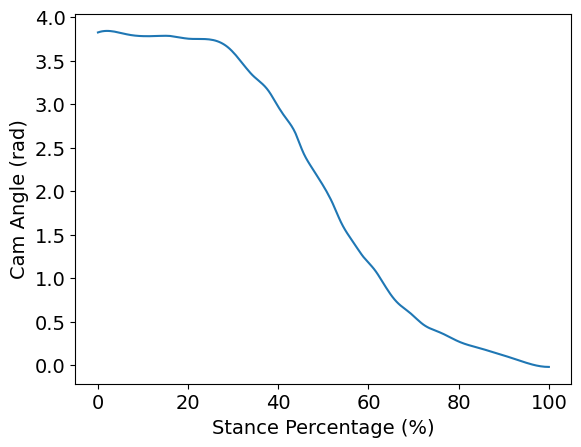

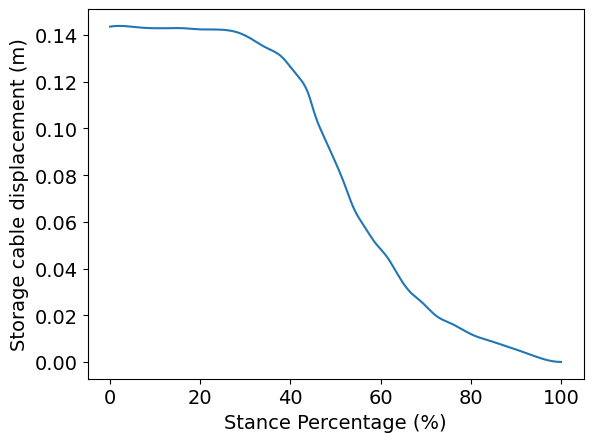

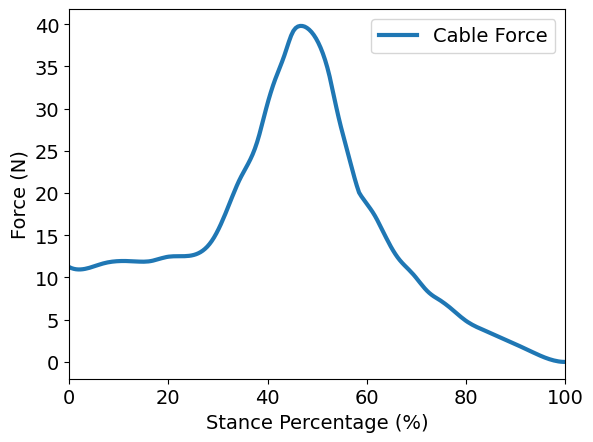

max force of 39.7932269590414  at  46.57534246575342  %
max radii =  0.05238695729745619
sitting force = 11.233809536705316
TOTAL ERROR =  85.5683120007148


In [3]:
# Reload the class_cam_generation module to get the latest version of the code.
# (Useful while editing the other file)
reload(class_cam_generation)
from class_cam_generation import CamGeneration

# Define cam parameters
gear_ratios = np.array([0.25, 0.25, 0.25, 0.15, 0.75, 1.5, 1.5, 0.75])
input_angles = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4])
scaling = np.array([1.5])

x = np.append(np.append(gear_ratios, input_angles), scaling)

radius_max, perc_force_max, force_max, force_sitting = generate_cam(x, plot=True)
error_total = (radius_max
                + abs(perc_force_max - target_percentage_max)
                + abs(force_max - target_force_max)
                + abs(force_sitting)
                )

print('max force of', force_max,' at ',perc_force_max, ' %')
print('max radii = ',radius_max)
print(f'sitting force = {force_sitting}')
# print(f'Max radius = {radius_max}, max_force_perc - 32.5 = {perc_force_max}, \
#         max_force_diff = {F[ind][2]}, sitting_force = {F[ind][3]}')
print('TOTAL ERROR = ', error_total)